In [1]:
##########################################
##### Single Cell Example Code - Analyzing Retina Single Nucleus RNA-Seq and ATAC-Seq #####
##########################################
#Created 09/21/2024
#Updated 09/23/2026

#Andreas Pfenning

In [2]:
### Resources ###
#https://satijalab.org/seurat/articles/pbmc3k_tutorial
#https://satijalab.org/seurat/articles/essential_commands.html

In [1]:
##########################################
##### Load the libraries #####
##########################################
#library(edgeR);
library(gplots);
library(ggplot2);
library('Seurat')
#library('ArchR');
#library(dplyr)


Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess


Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
##########################################
##### Read in the gene expression information #####
##########################################
#This is single nucleus multiome from the retina
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
retinaDataDir <- "/ocean/projects/bio240054p/shared/retina/GSE196235/";


##### Read in the information about each sample #####
retinaMx <- Read10X(retinaDataDir)



In [6]:
### Create a Seurat object from the data ####
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
retinaSO = CreateSeuratObject(counts = retinaMx, project = "retinaSnRNA-seq")

In [7]:
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
retinaSO


An object of class Seurat 
36601 features across 51645 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

In [8]:
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
retinaSubSO <- subset(x = retinaSO, idents = c("1", "2"))

In [9]:
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
retinaSubSO

An object of class Seurat 
36601 features across 10043 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

In [10]:
#NOTE: ONLY PROVIDED AS A REFERENCE - NO NEED TO RUN
rm(retinaMx)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3396057,181.4,6056140,323.5,6056140,323.5
Vcells,173607489,1324.6,478335400,3649.5,571912037,4363.4


In [2]:
#Save the file - For reference only. Students have this provided.
#saveRDS(retinaSubSO, file = "output/retinaSubSO_2samps.1.rds")

retinaObjFile <- "/ocean/projects/bio240054p/shared/retina/R_processed_data/retinaSubSO_2samps.1.rds";
retinaSubSO <- readRDS(retinaObjFile)

In [12]:
##########################################
##### Perform basic processing and quality control of the data #####
##########################################

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


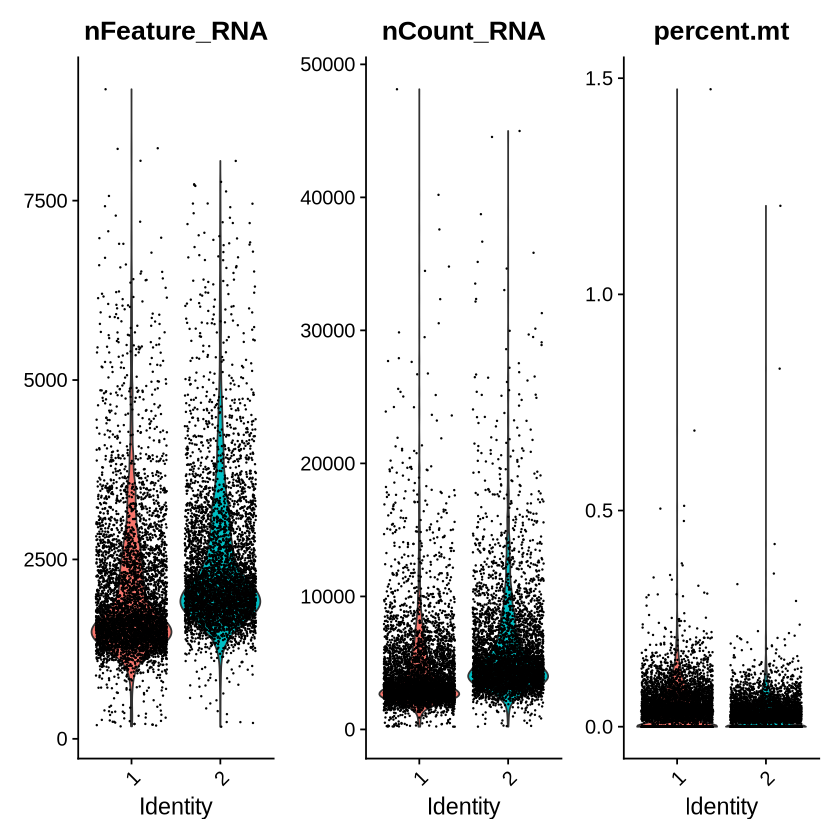

In [3]:
#Percent mitochondrial reads
#Why wouldn't you expect to see mitochondrial reads?
retinaSubSO[["percent.mt"]] <- PercentageFeatureSet(retinaSubSO, pattern = "^MT-")
VlnPlot(retinaSubSO, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)


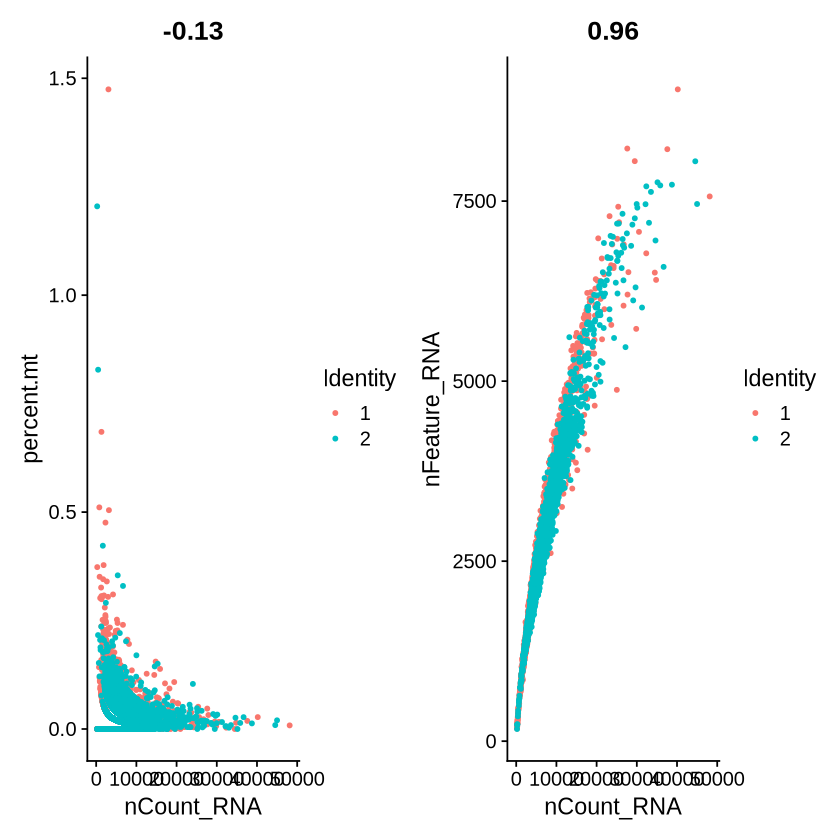

In [4]:
# FeatureScatter is typically used to visualize feature-feature relationships, but can be used
# for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

plot1 <- FeatureScatter(retinaSubSO, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(retinaSubSO, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [5]:
#### Normalize the raw counts ########
retinaSubSO <- NormalizeData(retinaSubSO, normalization.method = "LogNormalize", scale.factor = 10000)

Normalizing layer: counts



In [6]:
#### Find variables features ######
retinaSubSO <- FindVariableFeatures(retinaSubSO, selection.method = "vst", nfeatures = 2000)


Finding variable features for layer counts



In [7]:
#### Scale the data ######
allGenesV <- rownames(retinaSubSO)
retinaSubSO <- ScaleData(retinaSubSO, features = allGenesV)

Centering and scaling data matrix



In [2]:
#Save the intermediate file - For reference only. Students have this provided.
#saveRDS(retinaSubSO, file = "output/retinaSubSO_scaled_2samps.1.rds")
#cp output/retinaSubSO_scaled_2samps.1.rds /ocean/projects/bio240054p/shared/retina/R_processed_data/

retinaScaledObjFile <- "/ocean/projects/bio240054p/shared/retina/R_processed_data/retinaSubSO_scaled_2samps.1.rds";
retinaSubSO <- readRDS(retinaScaledObjFile)

In [3]:
retinaSubSO

An object of class Seurat 
36601 features across 10043 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [4]:
retinaSubSO2 <- subset(x = retinaSubSO, idents = c("1"))

In [6]:
retinaSubSO2

An object of class Seurat 
36601 features across 5175 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data

In [2]:
#Save the intermediate file - For reference only. Students have this provided.
#saveRDS(retinaSubSO2, file = "output/retinaSubSO_scaled_2samps.2.rds")
#cp output/retinaSubSO_scaled_2samps.2.rds /ocean/projects/bio240054p/shared/retina/R_processed_data/

retinaScaledObj2File <- "/ocean/projects/bio240054p/shared/retina/R_processed_data/retinaSubSO_scaled_2samps.2.rds";
retinaSubSO2 <- readRDS(retinaScaledObj2File)

In [3]:
#VariableFeatures(object = retinaSubSO)
gc();

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3306807,176.7,6242844,333.5,4398987,235.0
Vcells,227033871,1732.2,328825690,2508.8,227100729,1732.7


In [4]:
#Calculate the principle components of the data
retinaSubSO2 <- RunPCA(retinaSubSO2, features = VariableFeatures(object = retinaSubSO2),npcs = 30)


PC_ 1 
Positive:  GRIA4, GPM6A, FAM155A, NRXN3, NRG3, APP, PCDH9, CTNND2, GPR158, DTNA 
	   FRMD4A, MIR181A1HG, TENM4, BASP1, AC092691.1, DPP6, PAX6, NRXN1, MEG3, TRIO 
	   PLCB1, NAV3, TANC1, GNAQ, GRIA3, NAV2, DACH1, KHDRBS2, LRP1B, DPYSL2 
Negative:  CDH12, PRELID2, MEIS2, GUCA1C, PCAT4, LINC02296, DLGAP2, PRKCA, RHOBTB1, RPE65 
	   MEGF11, AL161716.1, LINC00457, GNGT2, SEPTIN4, ARR3, ALCAM, LINC02343, SLC25A21, CNGB3 
	   RAB41, LINC02096, LINC01440, CCBE1, AC023905.1, AC106798.1, AC112206.2, BEST1, OPN1LW, AC110992.1 
PC_ 2 
Positive:  WIF1, F3, SLC1A3, HKDC1, TF, FOXP2, FRZB, RLBP1, RGR, CP 
	   APOE, SLITRK2, ABI3BP, MYO3A, PRSS35, GPX3, CLU, KDR, SPP1, EGF 
	   GLUL, VIM, AC009041.2, GABRG3, CDH23, RRH, CFI, SELENOP, STAC2, PTGDS 
Negative:  MDGA2, RYR2, DGKI, ATRNL1, GRIA2, ROBO2, EDIL3, SLC4A10, DOK6, NRXN1 
	   PLCB4, NEBL, ADGRB3, OPCML, DLGAP1, STXBP5L, CA10, UNC5D, PDE4B, FMN2 
	   CNTNAP2, TENM2, DAB1, LRRC7, SNTG1, SPOCK3, KIF5C, LINC01414, RUNX1T1, SLC8A3 
PC_ 3 
Posit

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


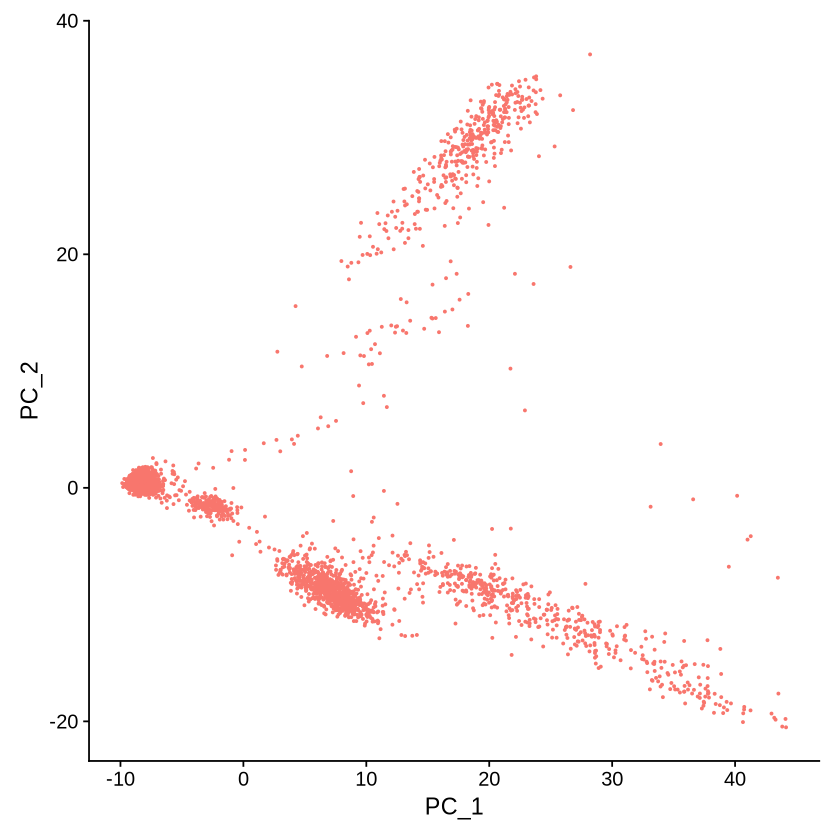

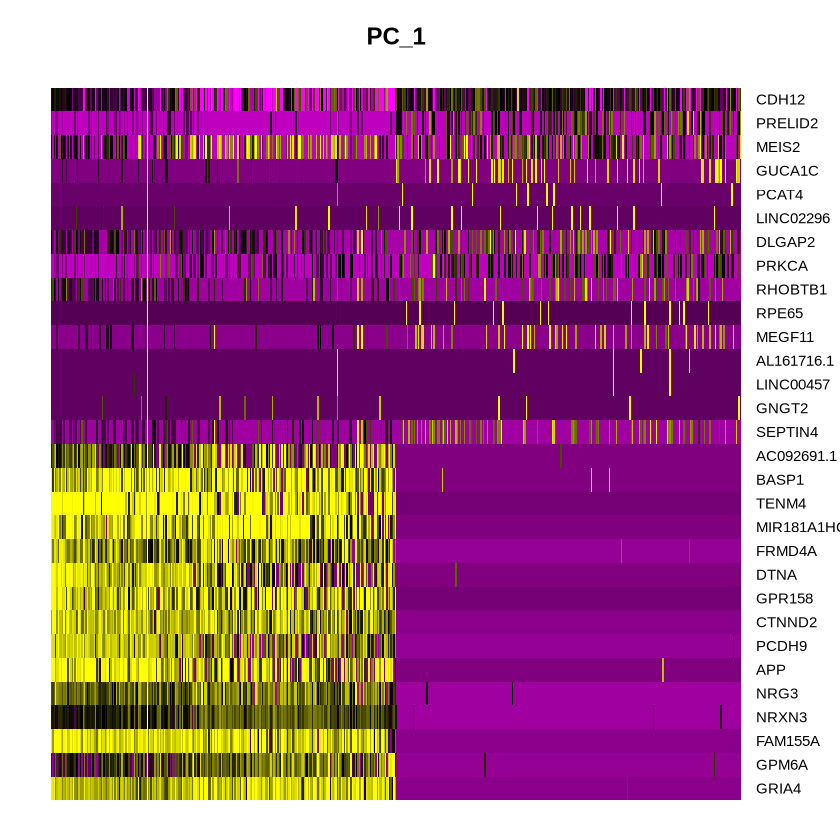

In [6]:
#Plot the results of the PCA
DimPlot(retinaSubSO2, reduction = "pca") + NoLegend()
DimHeatmap(retinaSubSO2, dims = 1, cells = 500, balanced = TRUE)

In [22]:
##########################################
##### Cluster and visualize the the cells #####
##########################################

In [7]:
#Create the clustering
retinaSubSO2 <- FindNeighbors(retinaSubSO2, dims = 1:10)
retinaSubSO2 <- FindClusters(retinaSubSO2, resolution = .3)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5175
Number of edges: 155923

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9305
Number of communities: 15
Elapsed time: 0 seconds


In [8]:
#Create UMPAP Dimension Reduction
retinaSubSO2 <- RunUMAP(retinaSubSO2, dims = 1:10)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:15:37 UMAP embedding parameters a = 0.9922 b = 1.112

09:15:37 Read 5175 rows and found 10 numeric columns

09:15:37 Using Annoy for neighbor search, n_neighbors = 30

09:15:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:15:38 Writing NN index file to temp file /var/tmp/RtmpJlhHpp/filef9101671e357

09:15:38 Searching Annoy index using 1 thread, search_k = 3000

09:15:40 Annoy recall = 100%

09:15:41 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbo

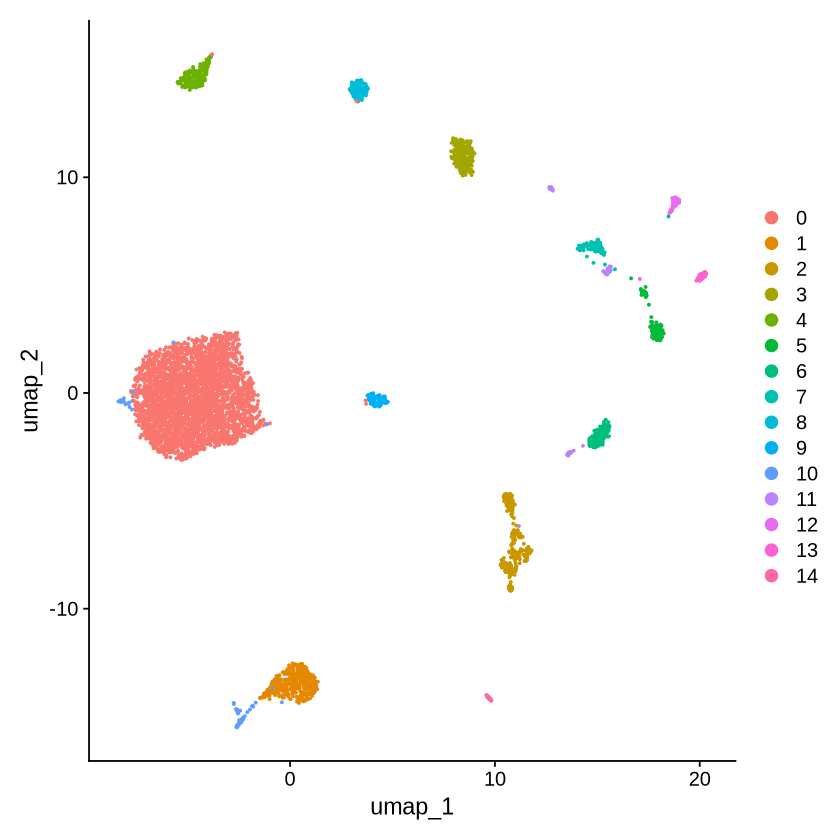

In [10]:
#Plot the UMAP
DimPlot(retinaSubSO2, reduction = "umap")


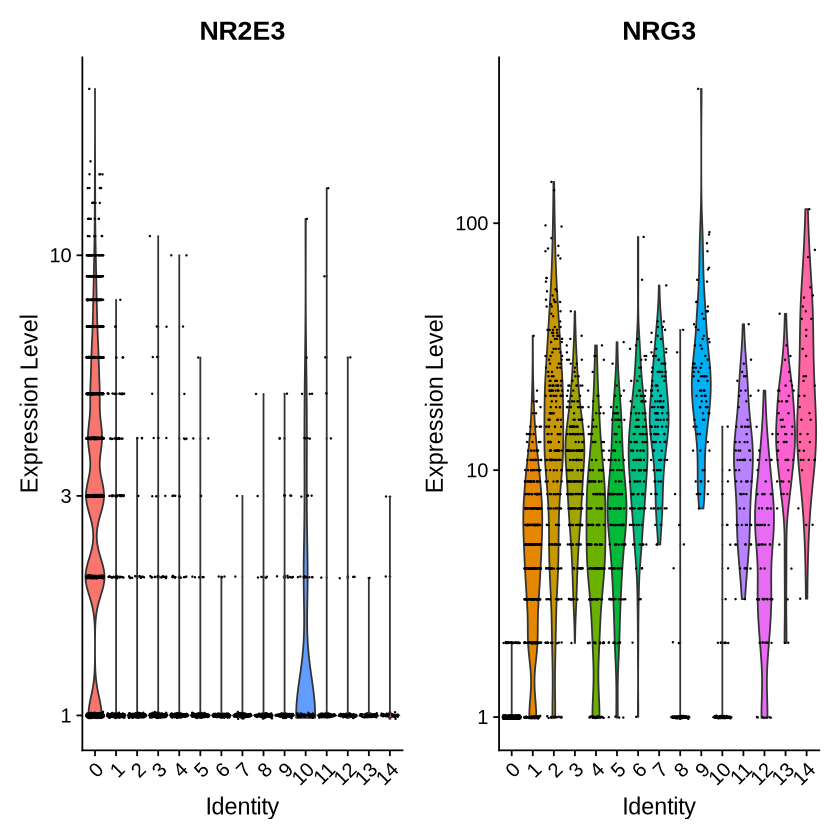

In [14]:
#Plot the raw counts features
VlnPlot(retinaSubSO2, features = c("NR2E3", "NRG3"), slot = "counts", log = TRUE)


Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


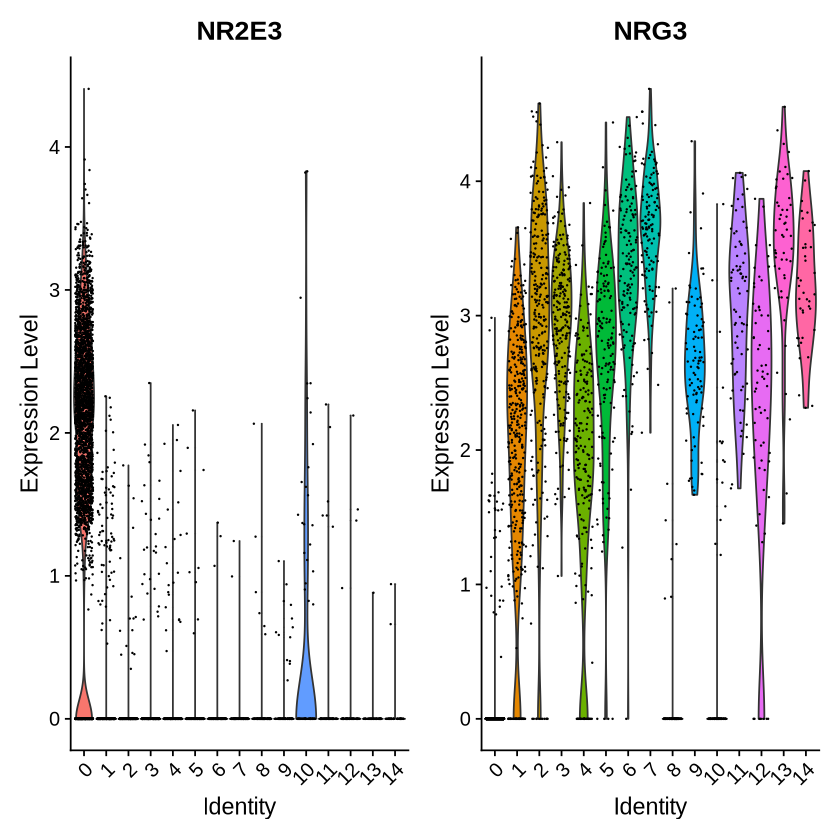

In [12]:
#Plot the normalized features
VlnPlot(retinaSubSO2, features = c("NR2E3", "NRG3"))

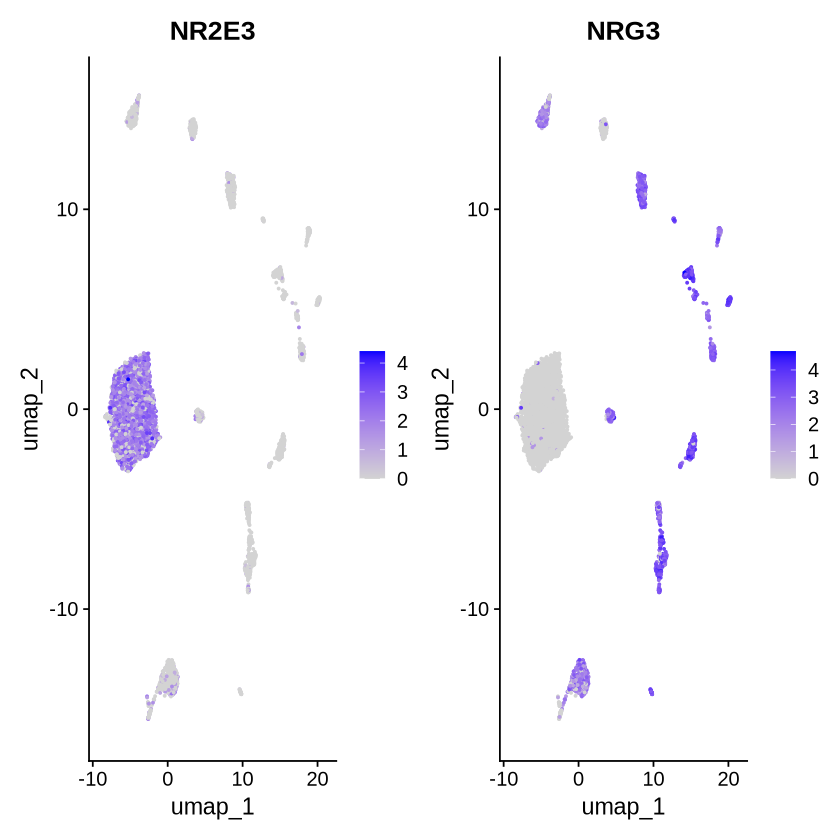

In [16]:
FeaturePlot(retinaSubSO2, features = c("NR2E3", "NRG3"))

In [ ]:
#Find the marker genes of cluster 0 - What cell type is it?
cluster0.markers <- FindMarkers(retinaSubSO2, ident.1 = 0, method='wilcox_limma')
#cluster0.markers <- FindMarkers(retinaSubSO, ident.1 = 0, method='roc')
head(cluster0.markers, n = 10)

#Compare to publicly available data
#https://eyemultiome.su.domains/#data

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session



In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
retinaSubSO.markers <- FindAllMarkers(retinaSubSO2, method='wilcox_limma', only.pos = TRUE, method='wilcox_limma')
retinaSubSO.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

Calculating cluster 0



In [ ]:
retinaSubSO.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10
DoHeatmap(retinaSubSO, features = top10$gene) + NoLegend()

In [ ]:
ggsave(filename="output/eyeMarkers.1.pdf",device="pdf",width=15,height=30)